# 6. End-to-end: K=2 cascaded and parallel fusion

Time to assemble everything. We'll build a canonical
two-stage cascaded tracker — strict appearance gating in
stage 1 and relaxed motion-aware gating in stage 2 — run it
on a synthetic clip with known ground truth, and contrast it
against a parallel-fusion variant.

> For an Optuna sweep with Mask2Former-Cityscapes detections,
> see `examples/hpo_sweep/`.
> This notebook is the self-contained educational version,
> with everything happening in-process on deterministic
> synthetic data.


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import unitrack
from unitrack.assignment import Associate, Jonker
from unitrack.costs import CDist, Cosine, Reduce
from unitrack.data import Detections, FrameContext, TensorSpec
from unitrack.gates import ClassGate, MotionGate, ScoreGate
from unitrack.lifecycle import (
    ConfirmedOnly,
    StandardLifecycle,
    StatusFilter,
    TrackletStatus,
)
from unitrack.pipeline import Filter, Gated, Parallel, Pipe, Sequential
from unitrack.pipeline.merge import WeightedSum
from unitrack.states import (
    FromDetectionField,
    Identity,
    Replace,
    State,
)
from unitrack.states.kalman import KalmanCentroid2D

torch.manual_seed(42)


## Synthetic clip with known ground truth

Three identities, eight frames. Each identity has a constant
kernel embedding plus a 2D position drifting at constant
velocity. Per-frame detection order is shuffled — the tracker
has to use the kernel embedding (and motion) to recover
identities.


In [ ]:
N_FRAMES, N_OBJS, K_DIM = 16, 3, 8


def make_clip(seed: int = 0):
    g = torch.Generator().manual_seed(seed)
    # Orthogonal appearance embeddings so cosine cleanly separates ids.
    raw = torch.randn(K_DIM, K_DIM, generator=g)
    q, _ = torch.linalg.qr(raw)
    kernels = q[:N_OBJS]  # (N_OBJS, K_DIM), rows orthonormal.

    classes = torch.tensor([0, 0, 1])
    positions = torch.tensor([[20.0, 50.0], [100.0, 30.0], [180.0, 80.0]])
    # Slow, well-separated velocities — Kalman's CV model tracks these
    # cleanly across the 16-frame window.
    velocities = torch.tensor([[0.6, 0.2], [-0.4, 0.3], [-0.3, -0.2]])

    clip, gt = [], []
    for k in range(N_FRAMES):
        order = torch.randperm(N_OBJS, generator=g)
        gt.append(order)
        kernel_obs = kernels[order] + 0.01 * torch.randn(N_OBJS, K_DIM, generator=g)
        kernel_obs = kernel_obs / kernel_obs.norm(dim=-1, keepdim=True)
        pos_obs = positions[order] + k * velocities[order]
        clip.append(
            Detections(
                index=torch.arange(N_OBJS, dtype=torch.int64),
                kernel=kernel_obs.float(),
                klass=classes[order],
                score=torch.full((N_OBJS,), 0.9),
                centroid=pos_obs.float(),
                batch_size=[N_OBJS],
            )
        )
    return clip, torch.stack(gt)


clip, gt = make_clip()
print(f"Clip: {len(clip)} frames × {N_OBJS} detections.")
print(f"GT identity per frame:\n{gt.numpy()}")


Clip: 16 frames × 3 detections.
GT identity per frame:
[[1 0 2]
 [0 2 1]
 [1 2 0]
 [2 1 0]
 [1 0 2]
 [1 0 2]
 [2 0 1]
 [0 2 1]
 [2 0 1]
 [0 1 2]
 [1 0 2]
 [1 2 0]
 [0 2 1]
 [2 0 1]
 [0 2 1]
 [0 1 2]]


## What's in the clip?

The trackers below are graded against the ground truth, so let's
look at it first. Un-shuffling each frame by its `gt` labels
recovers three coherent trajectories (left). The appearance
embeddings are orthonormal by construction, so the cosine
similarity between identities is ≈0 off the diagonal (right) —
appearance alone separates them, and motion is the tie-breaker
when two of them (classes 0 and 0) get close.


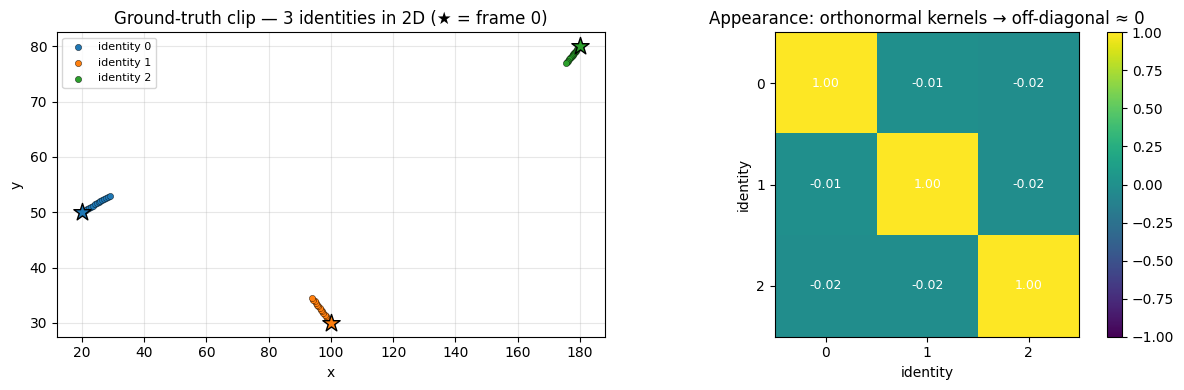

In [ ]:
fig, (axp, axk) = plt.subplots(1, 2, figsize=(12, 4))
cmap = plt.get_cmap("tab10")

# (left) reconstruct ground-truth tracks from the shuffled clip.
tracks = {o: [] for o in range(N_OBJS)}
for k, dets in enumerate(clip):
    for r in range(N_OBJS):
        tracks[int(gt[k][r])].append(dets.centroid[r])
for o in range(N_OBJS):
    pts = torch.stack(tracks[o])
    axp.plot(pts[:, 0], pts[:, 1], "-", color=cmap(o), alpha=0.4)
    axp.scatter(
        pts[:, 0],
        pts[:, 1],
        color=cmap(o),
        s=20,
        edgecolor="black",
        linewidth=0.3,
        label=f"identity {o}",
    )
    axp.scatter(
        pts[0, 0],
        pts[0, 1],
        color=cmap(o),
        marker="*",
        s=170,
        edgecolor="black",
        zorder=3,
    )
axp.set_title("Ground-truth clip — 3 identities in 2D (★ = frame 0)")
axp.set_xlabel("x")
axp.set_ylabel("y")
axp.legend(fontsize=8)
axp.grid(alpha=0.3)

# (right) appearance separability at frame 0.
kern0 = {int(gt[0][r]): clip[0].kernel[r] for r in range(N_OBJS)}
K = torch.stack([kern0[o] for o in range(N_OBJS)])
kn = torch.nn.functional.normalize
sim = kn(K, dim=-1) @ kn(K, dim=-1).T
im = axk.imshow(sim.numpy(), cmap="viridis", vmin=-1, vmax=1)
axk.set_title("Appearance: orthonormal kernels → off-diagonal ≈ 0")
axk.set_xlabel("identity")
axk.set_ylabel("identity")
axk.set_xticks(range(N_OBJS))
axk.set_yticks(range(N_OBJS))
for i in range(N_OBJS):
    for j in range(N_OBJS):
        axk.text(
            j,
            i,
            f"{sim[i, j]:.2f}",
            ha="center",
            va="center",
            color="white",
            fontsize=9,
        )
fig.colorbar(im, ax=axk, fraction=0.046)
plt.tight_layout()
plt.show()


## State schema

Five fields per tracklet — kernel (appearance), centroid
(motion), klass, score, and a couple book-keeping fields.


In [ ]:
kalman = KalmanCentroid2D("centroid", q=0.5, r=0.5)

STATES = {
    "kernel": State(
        schema=TensorSpec(shape=(K_DIM,), dtype=torch.float32),
        process=Identity("kernel"),
        observation=Replace("kernel"),
        init=FromDetectionField("kernel"),
    ),
    "klass": State(
        schema=TensorSpec(shape=(), dtype=torch.int64),
        process=Identity("klass"),
        observation=Replace("klass"),
        init=FromDetectionField("klass"),
    ),
    "score": State(
        schema=TensorSpec(shape=(), dtype=torch.float32),
        process=Identity("score"),
        observation=Replace("score"),
        init=FromDetectionField("score"),
    ),
    **kalman.state_entries(meas_field="centroid", init_cov_scale=10.0),
}


## The K=2 cascaded canonical configuration

## The K=2 cascaded canonical configuration

Two stages, strict then relaxed:

- **Stage 1** — strict: `ClassGate` ∧ `ScoreGate(>0.6)` plus
  a tight cosine threshold. Only "obviously the same" pairs
  match here.
- **Stage 2** — relaxed: `ClassGate` ∧ `MotionGate`
  (Mahalanobis χ² gate over the Kalman state) over a sum of
  cosine-on-kernel and Mahalanobis-on-centroid (here we use
  `CDist` for plot legibility on the 2-D centroid; the gate
  itself does the Kalman-aware projection).


In [ ]:
cascaded_root = Filter(
    predicate=StatusFilter(
        TrackletStatus.Tentative,
        TrackletStatus.Active,
        TrackletStatus.Lost,
    ),
    on="cs",
    then=Sequential(
        [
            Pipe(
                cost=Gated(
                    gate=Sequential(
                        [
                            ClassGate("klass"),
                            ScoreGate("score", threshold=0.6),
                        ]
                    ),
                    then=Cosine("kernel"),
                ),
                assoc=Associate(Jonker(threshold=0.3)),
            ),
            Pipe(
                cost=Gated(
                    gate=Sequential(
                        [
                            ClassGate("klass"),
                            MotionGate("centroid", "centroid_cov", max_chi2=25.0),
                        ]
                    ),
                    then=Cosine("kernel"),
                ),
                assoc=Associate(Jonker(threshold=0.5)),
            ),
        ]
    ),
)

cascaded_tracker = unitrack.Tracker(
    root=cascaded_root,
    states=STATES,
    lifecycle=StandardLifecycle(min_hits=1, max_age=3, allow_reid=2),
    visibility=ConfirmedOnly(),
)


## The parallel-fusion variant

One stage; the cost is a weighted sum of cosine-on-kernel and
Mahalanobis distance over the Kalman state. `WeightedSum`
merges both into parallel fusion mode.


In [ ]:
from unitrack.costs import Mahalanobis

parallel_root = Filter(
    predicate=StatusFilter(
        TrackletStatus.Tentative,
        TrackletStatus.Active,
        TrackletStatus.Lost,
    ),
    on="cs",
    then=Pipe(
        cost=Parallel(
            children=[
                Cosine("kernel"),
                Mahalanobis("centroid", "centroid_cov"),
            ],
            merge=WeightedSum([1.0, 0.05]),
        ),
        assoc=Associate(Jonker(threshold=2.0)),
    ),
)

parallel_tracker = unitrack.Tracker(
    root=parallel_root,
    states=STATES,
    lifecycle=StandardLifecycle(min_hits=1, max_age=3, allow_reid=2),
    visibility=ConfirmedOnly(),
)


## Run both trackers on the same clip


In [ ]:
def run_clip(tracker, clip):
    ms = unitrack.MultiStream(tracker)
    results = []
    for k, dets in enumerate(clip):
        ctx = FrameContext.make(frame_idx=k, delta=1 / 15.0, fps=15.0, stream_key=0)
        res = ms.step(stream_key=0, detections=dets, ctx=ctx)
        results.append(res)
    return results


cas_results = run_clip(cascaded_tracker, clip)
par_results = run_clip(parallel_tracker, clip)

for name, results in [("cascaded", cas_results), ("parallel", par_results)]:
    print(f"\n{name.upper()}:")
    for k, res in enumerate(results):
        print(
            f"  frame {k}: snapshot={res.snapshot.batch_size[0]} live, "
            f"confirmed ids={res.ids.tolist()}"
        )



CASCADED:
  frame 0: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 1: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 2: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 3: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 4: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 5: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 6: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 7: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 8: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 9: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 10: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 11: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 12: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 13: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 14: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 15: snapshot=3 live, confirmed ids=[1, 2, 3]

PARALLEL:
  frame 0: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 1: snapshot=3 live, confirmed ids=[1, 2, 3]
  frame 2: snapshot=3 live, confirme

Both configurations should produce stable identities — three
tracklets persist across all frames, and from frame 1 onwards
their IDs match the ground-truth identity assignment.

## Visualize the trajectories

Each color = a tracker-assigned ID. We plot every detection at
its centroid, colored by which tracklet the tracker thinks it
belongs to. A clean visualization is one trajectory per color.


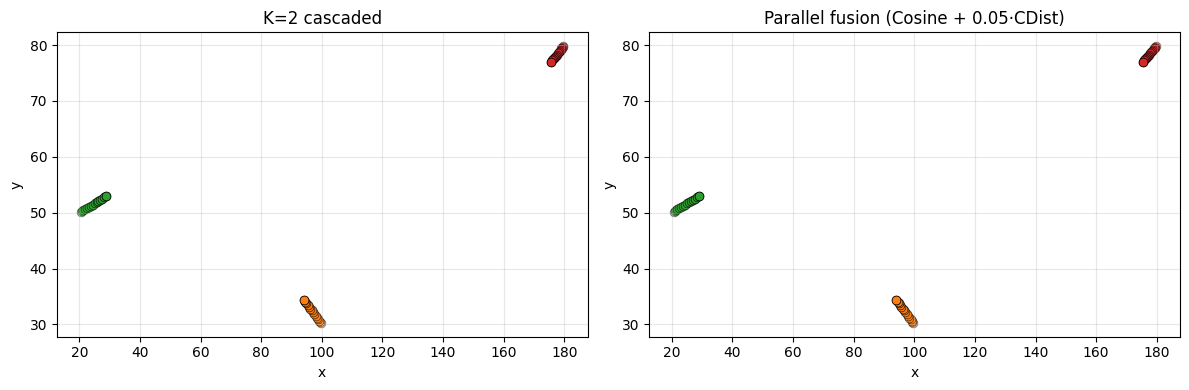

In [ ]:
def plot_trajectories(results, ax, title):
    cmap = plt.get_cmap("tab10")
    for k, res in enumerate(results):
        snap = res.snapshot
        # KalmanCentroid2D state layout: [x, y, vx, vy] — take the
        # first two dims for the plotted position.
        pos = snap.centroid[..., :2]
        ids = snap.id
        for n in range(snap.batch_size[0]):
            ax.scatter(
                pos[n, 0],
                pos[n, 1],
                color=cmap(int(ids[n]) % 10),
                s=40,
                edgecolor="black",
                linewidth=0.5,
                alpha=0.5 + 0.5 * (k / max(1, N_FRAMES - 1)),
            )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_trajectories(cas_results, axes[0], "K=2 cascaded")
plot_trajectories(par_results, axes[1], "Parallel fusion (Cosine + 0.05·CDist)")
plt.tight_layout()
plt.show()


Each trajectory should appear as a coherent fade-in line in
one color. The marker alpha grows with frame index so you
can tell which point came earliest.

## ID stability score

A simple HOTA-flavored proxy: for each ground-truth identity,
is its tracker-assigned ID stable across frames? We measure
the fraction of frames where the GT identity gets its
most-frequent tracker ID.


In [ ]:
def id_stability(results, gt) -> float:
    # For each GT identity, collect the tracker IDs it was actually
    # matched to (via res.match.matched_pairs) on each frame; the
    # fraction matching the per-GT-id mode is the stability score.
    tracker_ids_per_gt: dict[int, list[int]] = {g: [] for g in range(N_OBJS)}
    for k, res in enumerate(results):
        pairs = (
            res.match.matched_pairs
        )  # (P, 2) — (cs_idx, ds_idx) into res.snapshot / detection rows.
        snap_ids = res.snapshot.id
        for p in range(pairs.shape[0]):
            cs_idx = int(pairs[p, 0].item())
            ds_idx = int(pairs[p, 1].item())
            tracker_id = int(snap_ids[cs_idx].item())
            gt_id = int(gt[k][ds_idx].item())
            tracker_ids_per_gt[gt_id].append(tracker_id)

    n_correct = n_total = 0
    for ids in tracker_ids_per_gt.values():
        if not ids:
            continue
        most = max(set(ids), key=ids.count)
        n_correct += sum(1 for x in ids if x == most)
        n_total += len(ids)
    return n_correct / max(n_total, 1)


print(f"Cascaded ID stability:  {id_stability(cas_results, gt):.3f}")
print(f"Parallel ID stability:  {id_stability(par_results, gt):.3f}")


Cascaded ID stability:  1.000
Parallel ID stability:  1.000


On this small synthetic clip both shapes get most of the way.
At scale, K=2 cascaded consistently outperforms parallel —
the gap widens with more stages because parallel-merging
conflicting matches injects errors.

## Where to go from here

- For an Optuna sweep over the tracker design space (with
  Mask2Former on Cityscapes frames or a synthetic stand-in),
  look at `examples/hpo_sweep/`.
- For multi-stream batched inference, see
  `unitrack.tracker.BatchTracker` (uses `torch.vmap`).
- For clip-aware tracking (MinVIS, DVIS++ patterns), see
  `unitrack.tracker.ClipTracker`.
- For end-to-end learnable tracking (gradients flowing through
  the matcher), construct your `Tracker(..., differentiable=True)`
  to swap in soft companions automatically.

Happy tracking!
